# Eigen Decomposition

## Overview

Eigen decomposition (also called spectral decomposition) is a fundamental matrix factorization technique that breaks down a square matrix into its constituent eigenvectors and eigenvalues.

For a square matrix **M** of size $d \times d$:
$$\mathbf{M} = \mathbf{U}\mathbf{\Lambda}\mathbf{U}^T$$

Where:
- **U** = matrix of eigenvectors: $[\mathbf{q}_1, \mathbf{q}_2, ..., \mathbf{q}_d]$
- **Λ** = diagonal matrix of eigenvalues: $\text{diag}(\lambda_1, \lambda_2, ..., \lambda_d)$

## Key Concepts

### Eigenvalues and Eigenvectors

For a matrix **M**, a non-zero vector $\mathbf{q}$ and scalar $\lambda$ are an eigenvector and eigenvalue if:
$$\mathbf{M}\mathbf{q} = \lambda\mathbf{q}$$

This equation tells us that multiplying the matrix by its eigenvector only scales it by $\lambda$ (no direction change).

### Important Properties

1. **Only for square matrices**: Eigen decomposition is defined only for square matrices
2. **Symmetric matrices**: For symmetric matrices, eigenvectors are orthogonal
3. **Reconstruction**: $\mathbf{M} = \sum_{i=1}^{d} \lambda_i \mathbf{q}_i \mathbf{q}_i^T$
4. **Trace and Determinant**:
   - $\text{tr}(\mathbf{M}) = \sum_{i=1}^{d} \lambda_i$
   - $\det(\mathbf{M}) = \prod_{i=1}^{d} \lambda_i$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Example 1: Computing Eigen Decomposition

In [2]:
# Create a simple 2x2 symmetric matrix
M = np.array([[4, 2],
              [2, 3]])

print("Original Matrix M:")
print(M)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(M)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors (as columns):")
print(eigenvectors)

# Sort by eigenvalues in descending order
idx = eigenvalues.argsort()[::-1]
eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]

print("\n--- Sorted by eigenvalues (descending) ---")
print("Eigenvalues (sorted):", eigenvalues_sorted)
print("Eigenvectors (sorted):")
print(eigenvectors_sorted)

Original Matrix M:
[[4 2]
 [2 3]]

Eigenvalues:
[5.56155281 1.43844719]

Eigenvectors (as columns):
[[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]

--- Sorted by eigenvalues (descending) ---
Eigenvalues (sorted): [5.56155281 1.43844719]
Eigenvectors (sorted):
[[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]


## Verification: Reconstructing M from Eigen Decomposition

In [3]:
# Reconstruct M using M = U * Lambda * U^T
U = eigenvectors_sorted
Lambda = np.diag(eigenvalues_sorted)

M_reconstructed = U @ Lambda @ U.T

print("Reconstructed M (U @ Λ @ U^T):")
print(M_reconstructed)

print("\nOriginal M:")
print(M)

print("\nReconstruction Error (Frobenius norm):")
error = np.linalg.norm(M - M_reconstructed, 'fro')
print(f"{error:.2e}")

Reconstructed M (U @ Λ @ U^T):
[[4. 2.]
 [2. 3.]]

Original M:
[[4 2]
 [2 3]]

Reconstruction Error (Frobenius norm):
4.44e-16


## Verification: M*q = λ*q

In [4]:
# Verify the eigenvalue equation: M*q = λ*q
print("Verifying M*q = λ*q for each eigenvector:")
print()

for i in range(len(eigenvalues_sorted)):
    q = eigenvectors_sorted[:, i]
    lam = eigenvalues_sorted[i]
    
    Mq = M @ q
    lambda_q = lam * q
    
    print(f"Eigenvector {i+1}: q = {q}")
    print(f"  M*q = {Mq}")
    print(f"  λ*q = {lambda_q}")
    print(f"  Match: {np.allclose(Mq, lambda_q)}")
    print()

Verifying M*q = λ*q for each eigenvector:

Eigenvector 1: q = [0.78820544 0.61541221]
  M*q = [4.38364617 3.4226475 ]
  λ*q = [4.38364617 3.4226475 ]
  Match: True

Eigenvector 2: q = [-0.61541221  0.78820544]
  M*q = [-0.88523796  1.1337919 ]
  λ*q = [-0.88523796  1.1337919 ]
  Match: True



## Example 2: Larger Matrix with Rank Reduction

In [5]:
# Create a larger symmetric matrix
n = 5
A = np.random.randn(n, n)
M_large = A @ A.T  # Ensure it's positive semi-definite and symmetric

print(f"Shape of M_large: {M_large.shape}")

# Compute eigen decomposition
evals, evecs = np.linalg.eig(M_large)

# Sort by eigenvalues (descending)
idx = evals.argsort()[::-1]
evals_sorted = evals[idx]
evecs_sorted = evecs[:, idx]

print("\nEigenvalues (sorted):")
print(evals_sorted)

print("\nTrace of M:", np.trace(M_large))
print("Sum of eigenvalues:", np.sum(evals_sorted))

print("\nDeterminant of M:", np.linalg.det(M_large))
print("Product of eigenvalues:", np.prod(evals_sorted))

Shape of M_large: (5, 5)

Eigenvalues (sorted):
[13.29471652  4.58313201  3.01560023  1.68383256  0.05094072]

Trace of M: 22.628222027495298
Sum of eigenvalues: 22.628222027495305

Determinant of M: 15.760834572354197
Product of eigenvalues: 15.760834572354769


## Rank Reduction via Eigen Decomposition

Using only the top k eigenvalues/eigenvectors to create a lower-rank approximation

In [6]:
# Approximate M_large using only top k components
k = 2  # Keep only top 2 components

U_k = evecs_sorted[:, :k]
Lambda_k = np.diag(evals_sorted[:k])

# Low-rank approximation: M ≈ U_k * Lambda_k * U_k^T
M_approx = U_k @ Lambda_k @ U_k.T

print(f"Original matrix rank (numerical): {np.linalg.matrix_rank(M_large)}")
print(f"Approximated matrix rank: {np.linalg.matrix_rank(M_approx)}")

approx_error = np.linalg.norm(M_large - M_approx, 'fro')
original_norm = np.linalg.norm(M_large, 'fro')

print(f"\nApproximation error (Frobenius norm): {approx_error:.4f}")
print(f"Relative error: {(approx_error/original_norm)*100:.2f}%")

print(f"\nEigenvalues explained by top {k} components:")
explained_variance = np.sum(evals_sorted[:k]) / np.sum(evals_sorted)
print(f"Variance explained: {explained_variance*100:.2f}%")

Original matrix rank (numerical): 5
Approximated matrix rank: 2

Approximation error (Frobenius norm): 3.4542
Relative error: 23.85%

Eigenvalues explained by top 2 components:
Variance explained: 79.01%


## Visualization: Eigenvalues Scree Plot

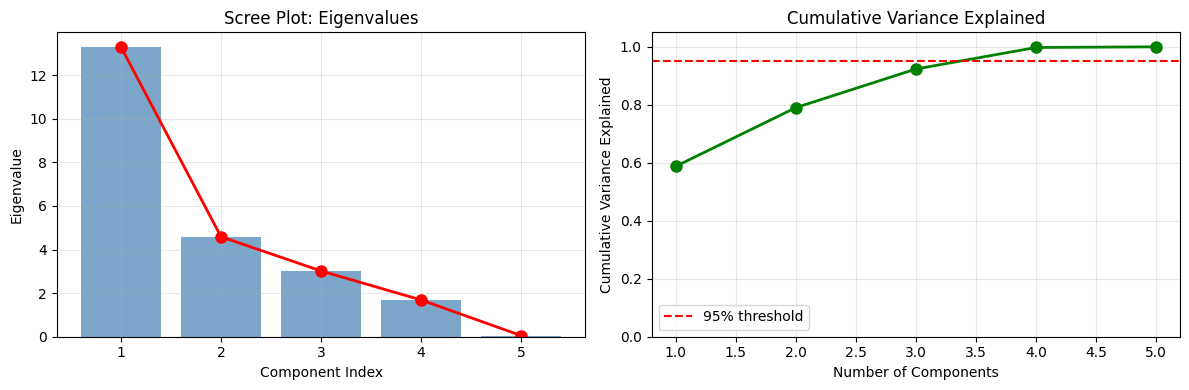

Cumulative variance explained by each component:
  Components 1-1: 58.75%
  Components 1-2: 79.01%
  Components 1-3: 92.33%
  Components 1-4: 99.77%
  Components 1-5: 100.00%


In [7]:
# Create a scree plot showing variance explained by each component
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
ax1.bar(range(1, len(evals_sorted)+1), evals_sorted, alpha=0.7, color='steelblue')
ax1.plot(range(1, len(evals_sorted)+1), evals_sorted, 'ro-', linewidth=2, markersize=8)
ax1.set_xlabel('Component Index')
ax1.set_ylabel('Eigenvalue')
ax1.set_title('Scree Plot: Eigenvalues')
ax1.grid(True, alpha=0.3)

# Cumulative variance explained
cumulative_var = np.cumsum(evals_sorted) / np.sum(evals_sorted)
ax2.plot(range(1, len(evals_sorted)+1), cumulative_var, 'go-', linewidth=2, markersize=8)
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("Cumulative variance explained by each component:")
for i, var in enumerate(cumulative_var):
    print(f"  Components 1-{i+1}: {var*100:.2f}%")

## Application: Principal Component Analysis (PCA)

In [8]:
# Generate 2D data with correlation
n_samples = 100
x = np.random.randn(n_samples)
y = x + 0.5 * np.random.randn(n_samples)

X = np.column_stack([x, y])

# Standardize
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_normalized = (X - X_mean) / X_std

# Compute covariance matrix
cov_matrix = np.cov(X_normalized.T)
print("Covariance Matrix:")
print(cov_matrix)

# Eigen decomposition of covariance matrix
evals_cov, evecs_cov = np.linalg.eig(cov_matrix)
idx_cov = evals_cov.argsort()[::-1]
evals_cov = evals_cov[idx_cov]
evecs_cov = evecs_cov[:, idx_cov]

print("\nEigenvalues of covariance matrix:", evals_cov)
print("Eigenvectors (principal components):")
print(evecs_cov)

Covariance Matrix:
[[1.01010101 0.88287671]
 [0.88287671 1.01010101]]

Eigenvalues of covariance matrix: [1.89297772 0.1272243 ]
Eigenvectors (principal components):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


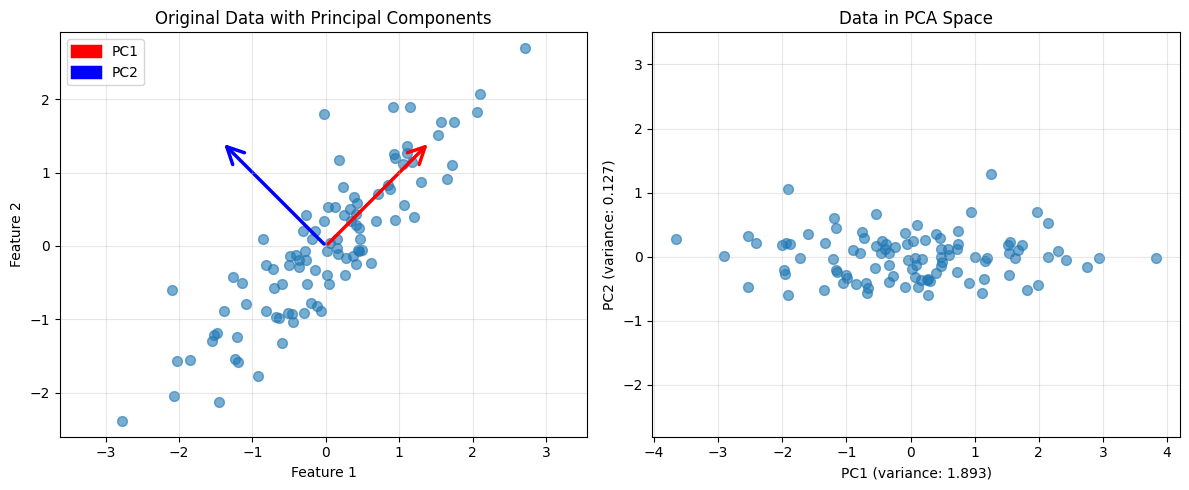

In [10]:
# Project data onto principal components
X_pca = X_normalized @ evecs_cov

# Visualize original data and principal components
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original data with principal axes
ax = axes[0]
ax.scatter(X_normalized[:, 0], X_normalized[:, 1], alpha=0.6, s=50)

# Plot principal components as arrows
for i in range(2):
    arrow = FancyArrowPatch((0, 0), 
                           (evecs_cov[0, i] * 2, evecs_cov[1, i] * 2),
                           arrowstyle='->', mutation_scale=30, 
                           linewidth=2.5, color=['red', 'blue'][i],
                           label=f'PC{i+1}')
    ax.add_patch(arrow)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Original Data with Principal Components')
ax.grid(True, alpha=0.3)
ax.legend()
ax.axis('equal')

# Data projected onto principal components
ax = axes[1]
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=50)
ax.set_xlabel(f'PC1 (variance: {evals_cov[0]:.3f})')
ax.set_ylabel(f'PC2 (variance: {evals_cov[1]:.3f})')
ax.set_title('Data in PCA Space')
ax.grid(True, alpha=0.3)
ax.axis('equal')

plt.tight_layout()
plt.show()

## Dimensionality Reduction with PCA

In [11]:
# Project to 1D (only first principal component)
X_pca_1d = X_pca[:, :1]

# Reconstruct from 1D PCA
X_reconstructed_1d = X_pca_1d @ evecs_cov[:, :1].T

# Reconstruction error
reconstruction_error = np.linalg.norm(X_normalized - X_reconstructed_1d, 'fro')
original_norm = np.linalg.norm(X_normalized, 'fro')

print(f"Original data shape: {X_normalized.shape}")
print(f"1D PCA projection shape: {X_pca_1d.shape}")
print(f"Reconstruction error: {reconstruction_error:.4f}")
print(f"Relative error: {(reconstruction_error/original_norm)*100:.2f}%")
print(f"Compression ratio: {(X_normalized.size / X_pca_1d.size):.1f}x")

Original data shape: (100, 2)
1D PCA projection shape: (100, 1)
Reconstruction error: 3.5490
Relative error: 25.10%
Compression ratio: 2.0x


## Special Cases

### 1. Symmetric Positive Definite Matrices

For symmetric positive definite (SPD) matrices:
- All eigenvalues are positive
- Eigenvectors are orthonormal
- Matrix is invertible
- Useful for covariance matrices

In [12]:
# Create a symmetric positive definite matrix
A_spd = np.random.randn(3, 3)
M_spd = A_spd @ A_spd.T  # Guaranteed to be SPD

evals_spd, evecs_spd = np.linalg.eig(M_spd)

print("SPD Matrix eigenvalues:")
print(evals_spd)
print("All positive:", np.all(evals_spd > 0))

# Check orthonormality of eigenvectors
orthogonality_check = evecs_spd.T @ evecs_spd
print("\nOrthogonality check (U^T @ U, should be identity):")
print(np.round(orthogonality_check, 10))

SPD Matrix eigenvalues:
[0.02001465 2.76901016 1.54291635]
All positive: True

Orthogonality check (U^T @ U, should be identity):
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]


### 2. Defective Matrices

Not all matrices can be diagonalized via eigen decomposition. Defective matrices have fewer linearly independent eigenvectors than their dimension. These require Jordan Normal Form instead.

In [13]:
# Example of a defective matrix (Jordan block)
# A 2x2 Jordan block with eigenvalue λ = 2
M_defective = np.array([[2, 1],
                        [0, 2]], dtype=float)

evals_def, evecs_def = np.linalg.eig(M_defective)

print("Defective matrix:")
print(M_defective)
print("\nEigenvalues:", evals_def)
print("\nEigenvectors:")
print(evecs_def)

# Check if the matrix is singular (cannot be diagonalized)
rank_defect = 2 - np.linalg.matrix_rank(evecs_def)
print(f"\nNumber of linearly independent eigenvectors: {np.linalg.matrix_rank(evecs_def)}")
print(f"Expected for diagonalization: 2")
print(f"This matrix is defective (cannot be diagonalized)" if rank_defect > 0 else "This matrix can be diagonalized")

Defective matrix:
[[2. 1.]
 [0. 2.]]

Eigenvalues: [2. 2.]

Eigenvectors:
[[ 1.0000000e+00 -1.0000000e+00]
 [ 0.0000000e+00  4.4408921e-16]]

Number of linearly independent eigenvectors: 1
Expected for diagonalization: 2
This matrix is defective (cannot be diagonalized)


## Computational Complexity

- **Dense eigendecomposition**: O(n³) time complexity
- **For large matrices**: Use sparse/iterative methods (power iteration, Lanczos algorithm)
- **NumPy/SciPy**: Optimized LAPACK routines under the hood

In [14]:
import time

# Test computation time for different matrix sizes
sizes = [10, 50, 100, 200]
times = []

for size in sizes:
    A = np.random.randn(size, size)
    M = A @ A.T
    
    start = time.time()
    evals, evecs = np.linalg.eig(M)
    elapsed = time.time() - start
    times.append(elapsed)
    
    print(f"Matrix size {size}x{size}: {elapsed*1000:.2f} ms")

print("\nNote: O(n³) growth - as n doubles, time increases ~8x")

Matrix size 10x10: 0.94 ms
Matrix size 50x50: 1.86 ms
Matrix size 100x100: 8.48 ms
Matrix size 200x200: 26.60 ms

Note: O(n³) growth - as n doubles, time increases ~8x


## Summary

**Key Takeaways:**

1. **Eigen decomposition** factorizes a matrix into eigenvectors and eigenvalues
2. **Only for square matrices**, most useful for symmetric matrices
3. **Eigenvectors** capture directions of maximum variance
4. **Eigenvalues** represent the magnitude of variance in each direction
5. **Applications**: PCA, matrix approximation, data compression, solving differential equations
6. **Not all matrices** can be diagonalized (defective matrices)
7. **Computational cost** is O(n³), limiting practical use for very large dense matrices

**When to use:**
- Dimensionality reduction (PCA)
- Understanding data covariance structure
- Matrix approximation and compression
- Analyzing dynamical systems
- Graph analysis (spectral methods)